In [1]:
%reload_ext autoreload
%autoreload 2

import iminuit
from fastfeedback import *

# Loading the CAFs data

data_manager = DataManager("/storage/1/st15719/caf_new_sum.2.6M_weighted.root")

# Defining the binning for the true and reco energy and coszenith
Ebins = np.logspace(-1, 1, 200)
Czbins = np.linspace(-1, 1, 100)
Ebins_reco = np.logspace(-1, 1, 50)
Czbins_reco = np.linspace(-1, 1, 20)

latex_names = {
    Flavor.NuE: r"$\nu_e$",
    Flavor.NuMu: r"$\nu_\mu$",
    Flavor.NuMuBar: r"$\bar{\nu}_\mu$",
    Flavor.NuEBar: r"$\bar{\nu}_e$",
    Flavor.NuTau: r"$\bar{\nu}_\tau$",
    Flavor.NuTauBar: r"$\bar{\nu}_\tau$",
}

ktyr = 25
eff_exposure = 160000 / ktyr

method_combinations = [
    0b0000,
    0b0001,
    0b0010,
    0b0100,
    0b1000,
    0b1111,
    0b1110,
    0b1101,
    0b1011,
    0b0111,
]
method_combinations_nunubar_eff = [
    0b000,
    0b001,
    0b010,
    0b100,
    0b111,
    0b110,
    0b101,
    0b010,
]

Loading data...


/software/xn22103/miniconda/envs/dune-atmo-osc/lib/python3.12/site-packages/awkward/_nplikes/array_module.py:454: RuntimeWarning: invalid value encountered in cast
  return self._module.concatenate(arrays, axis=axis, casting="same_kind")


Finished loading data with unique indices


In [ ]:
# Preparing the data with the default settings, of the current reco performances
def plot_reco_combos(method: int, mh: MH):
    direc_reco = Method.Truth if method & 1 << 0 else Method.Reco
    energy_reco = Method.Truth if method & 1 << 1 else Method.Reco
    flavor_disc = Method.Truth if method & 1 << 2 else Method.Reco
    nunubar_disc = Method.Truth if method & 1 << 3 else Method.Reco

    data_manager.set_direc_reco(direc_reco)
    data_manager.set_energy_reco(energy_reco)
    data_manager.set_flavor_discrimination(flavor_disc)
    data_manager.set_nunubar_discrimination(nunubar_disc)

    data = data_manager.prepare_data()

    # Creating the events distribution
    events = EventDistrib(
        data, Ebins, Czbins, Ebins_reco, Czbins_reco, exposure=eff_exposure
    )

    null_hyps = [
        get_nufit(mh),
        get_nufit(mh),
    ]
    null_hyps[0].dcp = 0
    null_hyps[1].dcp = np.pi / 2

    ref_event_rates = []

    for null_hyp in null_hyps:
        events.compute_osc(null_hyp)
        ref_event_rates.append(
            {fl: events.detected_events(fl) for fl in events.detected_channels}
        )

    LnL_values_nofit = [[] for _ in range(len(null_hyps))]
    dcp_scan = np.linspace(-np.pi, np.pi, 40)
    for dcp in dcp_scan:
        alt_hyp = get_nufit(mh)
        alt_hyp.dcp = dcp

        events.compute_osc(alt_hyp)

        expected = {fl: events.detected_events(fl) for fl in events.detected_channels}

        for i in range(len(null_hyps)):
            # Computing the LnL values
            llh = sum(
                LnL(ref_event_rates[i][ch], expected[ch])
                for ch in events.detected_channels
            )
            LnL_values_nofit[i].append(llh)

    plt.figure()
    plt.plot(dcp_scan, LnL_values_nofit[0], label=f"{mh.name}, dcp=0")
    plt.plot(dcp_scan, LnL_values_nofit[1], label=f"{mh.name}, dcp=π/2")

    plt.xlabel(r"$\delta_{CP}$")
    plt.ylabel("Log likelihood")
    plt.title(
        f"Direction={direc_reco.name}, Energy={energy_reco.name}, Flavor={flavor_disc.name}, Nu-Nubar={nunubar_disc.name}"
    )
    plt.legend()
    plt.show()


for method in method_combinations:
    for mh in MH:
        plot_reco_combos(method, mh)

In [ ]:
def plot_reco_combos_nunubar_eff(
    method: int, flavors: dict[Flavor, int | float], plot_sum=True
):
    direc_reco = Method.Truth if method & 1 << 0 else Method.Reco
    energy_reco = Method.Truth if method & 1 << 1 else Method.Reco
    flavor_disc = Method.Truth if method & 1 << 2 else Method.Reco

    data_manager.set_direc_reco(direc_reco)
    data_manager.set_energy_reco(energy_reco)
    data_manager.set_flavor_discrimination(flavor_disc)

    efficiencies = {
        Flavor.NuE: flavors.get(Flavor.NuE, 1),
        Flavor.NuEBar: flavors.get(Flavor.NuEBar, 1),
        Flavor.NuMu: flavors.get(Flavor.NuMu, 1),
        Flavor.NuMuBar: flavors.get(Flavor.NuMuBar, 1),
        Flavor.NuTau: flavors.get(Flavor.NuTau, 1),
        Flavor.NuTauBar: flavors.get(Flavor.NuTauBar, 1),
        Flavor.NC: flavors.get(Flavor.NC, 1),
    }
    nunubar = FakeEfficiency(efficiencies)
    data_manager.set_nunubar_discrimination(Method.Efficiency, nunubar)
    data = data_manager.prepare_data()
    events = EventDistrib(
        data, Ebins, Czbins, Ebins_reco, Czbins_reco, exposure=eff_exposure
    )

    # Gets the standard oscillation parameters
    pars = get_nufit(MH.Normal)
    # Compute the events with the standard oscillation parameters
    events.compute_osc(pars)
    # Saving the reference event rates
    ref_event_rates = {
        fl: events.detected_events(fl) for fl in events.detected_channels
    }

    LnL_values = {fl: [] for fl in events.detected_channels}

    # Sampling dcp values
    sampling = np.linspace(0, 2 * np.pi, 50)
    for val in sampling:
        # Setting the dcp value
        pars.dcp = val
        # Computing the events with the new dcp value
        events.compute_osc(pars)
        # Saving the expected event rates
        expected = {fl: events.detected_events(fl) for fl in events.detected_channels}

        # Computing the LnL values
        for ch in events.detected_channels:
            LnL_values[ch].append(LnL(ref_event_rates[ch], expected[ch]))

    # Converting the lists to numpy arrays
    LnL_values = {fl: np.array(values) for fl, values in LnL_values.items()}

    sum = 0
    for ch, values in LnL_values.items():
        if ch not in flavors:
            continue

        if plot_sum:
            sum += values

        if len(flavors) == 1:
            plt.plot(
                sampling,
                values,
                label=f"{latex_names[ch]} Dir={direc_reco.name[0]}, E={energy_reco.name[0]}, Fl={flavor_disc.name[0]}",
            )
        else:
            plt.plot(sampling, values, label=latex_names[ch])

    if plot_sum:
        plt.plot(sampling, sum, label="Sum")
    plt.xlabel(r"$\delta_{CP}$")
    plt.ylabel("Log likelihood")
    if len(flavors) > 1:
        plt.title(
            f"Direction={direc_reco.name}, Energy={energy_reco.name}, Flavor={flavor_disc.name}"
        )
    plt.legend()

In [ ]:
for method in method_combinations_nunubar_eff:
    plt.figure()
    plot_reco_combos_nunubar_eff(
        method, {Flavor.NuE: 1, Flavor.NuEBar: 1, Flavor.NuMu: 1, Flavor.NuMuBar: 1}
    )
    plt.show()

In [ ]:
plt.figure()
for method in method_combinations_nunubar_eff:
    plot_reco_combos_nunubar_eff(method, {Flavor.NuE: 1}, False)
plt.show()

In [2]:
def plot_hesse_errors(method: int, results: list):
    direc_reco = Method.Truth if method & 1 << 0 else Method.Reco
    energy_reco = Method.Truth if method & 1 << 1 else Method.Reco
    flavor_disc = Method.Truth if method & 1 << 2 else Method.Reco
    nunubar_disc = Method.Truth if method & 1 << 3 else Method.Reco

    data_manager.set_direc_reco(direc_reco)
    data_manager.set_energy_reco(energy_reco)
    data_manager.set_flavor_discrimination(flavor_disc)
    data_manager.set_nunubar_discrimination(nunubar_disc)

    data = data_manager.prepare_data()

    # Creating the events distribution
    events = EventDistrib(data, Ebins, Czbins, Ebins_reco, Czbins_reco)

    # Gets the standard oscillation parameters
    pars = get_nufit(MH.Normal)
    # Compute the events with the standard oscillation parameters
    events.compute_osc(pars)
    # Saving the reference event rates
    ref_event_rates = {
        fl: events.detected_events(fl) for fl in events.detected_channels
    }

    LnL_values = {fl: [] for fl in events.detected_channels}

    # Sampling dcp values
    sampling = np.linspace(0, 2 * np.pi, 50)
    for val in sampling:
        # Setting the dcp value
        pars.dcp = val
        # Computing the events with the new dcp value
        events.compute_osc(pars)
        # Saving the expected event rates
        expected = {fl: events.detected_events(fl) for fl in events.detected_channels}

        # Computing the LnL values
        for ch in events.detected_channels:
            LnL_values[ch].append(LnL(ref_event_rates[ch], expected[ch]))

    # Converting the lists to numpy arrays
    LnL_values = {fl: np.array(values) for fl, values in LnL_values.items()}

    def loss(dm21, dm31, th12, th13, th23, dcp):
        pars = ROOT.OscPars()
        pars.dm21 = dm21
        pars.dm31 = dm31
        pars.th12 = th12
        pars.th13 = th13
        pars.th23 = th23
        pars.dcp = dcp

        events.compute_osc(pars)
        # Saving the expected event rates
        expected = {fl: events.detected_events(fl) for fl in events.detected_channels}
        total_loss = sum(
            LnL(ref_event_rates[ch], expected[ch]) for ch in events.detected_channels
        )
        return total_loss

    nufit = get_nufit(MH.Normal)

    fitter = iminuit.Minuit(
        loss,
        dm21=nufit.dm21,
        dm31=nufit.dm31,
        th12=nufit.th12,
        th13=nufit.th13,
        th23=nufit.th23,
        dcp=nufit.dcp,
    )

    hesse = fitter.hesse()
    dcp_err = hesse.errors["dcp"]
    dcp_best_fit = hesse.values["dcp"]

    results.append(
        {
            "Method ID": bin(method),
            "Direction": direc_reco.name,
            "Energy": energy_reco.name,
            "Flavor": flavor_disc.name,
            "Nu-Nubar": nunubar_disc.name,
            "dCP Best Fit": dcp_best_fit,
            "dCP Error": dcp_err,
        }
    )


results = []
for method in method_combinations:
    plot_hesse_errors(method, results)

display(pl.DataFrame(results))

Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...
Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...
Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...
Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...
Filling histograms...
Using the following detected output channels: ['NuMuBar', 'NuEBar', 'NC', 'NuE', 'NuMu']
Finished filling histograms...
Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...
Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...
Filling histograms...
Us

Method ID,Direction,Energy,Flavor,Nu-Nubar,dCP Best Fit,dCP Error
str,str,str,str,str,f64,f64
"""0b0""","""Reco""","""Reco""","""Reco""","""Reco""",3.700098,1.868783
"""0b1""","""Truth""","""Reco""","""Reco""","""Reco""",3.700098,0.577539
"""0b10""","""Reco""","""Truth""","""Reco""","""Reco""",3.700098,1.453232
"""0b100""","""Reco""","""Reco""","""Truth""","""Reco""",3.700098,1.744366
"""0b1000""","""Reco""","""Reco""","""Reco""","""Truth""",3.700098,1.442257
"""0b1111""","""Truth""","""Truth""","""Truth""","""Truth""",3.700098,0.360077
"""0b1110""","""Reco""","""Truth""","""Truth""","""Truth""",3.700098,1.340439
"""0b1101""","""Truth""","""Reco""","""Truth""","""Truth""",3.700098,0.5316
"""0b1011""","""Truth""","""Truth""","""Reco""","""Truth""",3.700098,0.318886


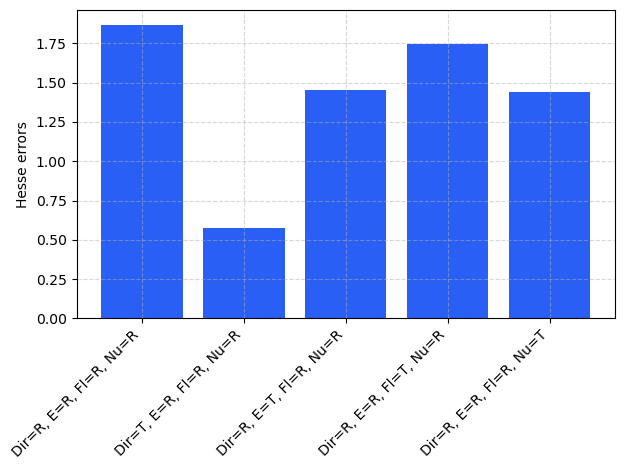

In [3]:
plt.figure()
for r in results[:5]:
    plt.bar(
        f"Dir={r['Direction'][0]}, E={r['Energy'][0]}, Fl={r['Flavor'][0]}, Nu={r['Nu-Nubar'][0]}",
        r["dCP Error"],
        color="#295FF4",
    )
    plt.xticks(rotation=45, ha="right")
plt.ylabel("Hesse errors")
plt.grid(visible=True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("hesse-errors.svg")

In [ ]:
def plot_nunubar_efficiencies(method: int, flavors: dict[Flavor, int | float]):
    direc_reco = Method.Truth if method & 1 << 0 else Method.Reco
    energy_reco = Method.Truth if method & 1 << 1 else Method.Reco
    flavor_disc = Method.Truth if method & 1 << 2 else Method.Reco

    data_manager.set_direc_reco(direc_reco)
    data_manager.set_energy_reco(energy_reco)
    data_manager.set_flavor_discrimination(flavor_disc)

    efficiencies = {
        Flavor.NuE: flavors.get(Flavor.NuE, 1.0),
        Flavor.NuEBar: flavors.get(Flavor.NuEBar, 1.0),
        Flavor.NuMu: flavors.get(Flavor.NuMu, 1.0),
        Flavor.NuMuBar: flavors.get(Flavor.NuMuBar, 1.0),
        Flavor.NuTau: flavors.get(Flavor.NuTau, 1.0),
        Flavor.NuTauBar: flavors.get(Flavor.NuTauBar, 1.0),
        Flavor.NC: flavors.get(Flavor.NC, 1.0),
    }
    nunubar = FakeEfficiency(efficiencies)
    data_manager.set_nunubar_discrimination(Method.Efficiency, nunubar)
    data = data_manager.prepare_data()
    events = EventDistrib(
        data, Ebins, Czbins, Ebins_reco, Czbins_reco, exposure=eff_exposure
    )

    # Gets the standard oscillation parameters
    pars = get_nufit(MH.Normal)
    # Compute the events with the standard oscillation parameters
    events.compute_osc(pars)
    # Saving the reference event rates
    ref_event_rates = {
        fl: events.detected_events(fl) for fl in events.detected_channels
    }

    LnL_values = {fl: [] for fl in events.detected_channels}

    # Sampling dcp values
    sampling = np.linspace(0, 2 * np.pi, 50)
    for val in sampling:
        # Setting the dcp value
        pars.dcp = val
        # Computing the events with the new dcp value
        events.compute_osc(pars)
        # Saving the expected event rates
        expected = {fl: events.detected_events(fl) for fl in events.detected_channels}

        # Computing the LnL values
        for ch in events.detected_channels:
            LnL_values[ch].append(LnL(ref_event_rates[ch], expected[ch]))

    # Converting the lists to numpy arrays
    LnL_values = {fl: np.array(values) for fl, values in LnL_values.items()}

    for ch, values in LnL_values.items():
        if ch not in flavors:
            continue

        plt.plot(
            sampling,
            values,
            label=f"{latex_names[ch]} Eff={efficiencies[ch]:.1f}",
        )

    plt.xlabel(r"$\delta_{CP}$")
    plt.ylabel("Log likelihood")
    plt.title(
        f"Direction={direc_reco.name}, Energy={energy_reco.name}, Flavor={flavor_disc.name}"
    )


for method in method_combinations_nunubar_eff:
    plt.figure()
    for efficiency in np.linspace(0, 1, 11):
        plot_nunubar_efficiencies(method, {Flavor.NuE: efficiency})
    plt.legend()
    plt.show()

In [ ]:
def plot_hesse_errors_nunubar_eff(method: int, flavor: Flavor, efficiency: float = 1.0):
    direc_reco = Method.Truth if method & 1 << 0 else Method.Reco
    energy_reco = Method.Truth if method & 1 << 1 else Method.Reco
    flavor_disc = Method.Truth if method & 1 << 2 else Method.Reco

    data_manager.set_direc_reco(direc_reco)
    data_manager.set_energy_reco(energy_reco)
    data_manager.set_flavor_discrimination(flavor_disc)

    efficiencies = {
        Flavor.NuE: 1.0,
        Flavor.NuEBar: 1.0,
        Flavor.NuMu: 1.0,
        Flavor.NuMuBar: 1.0,
        Flavor.NuTau: 1.0,
        Flavor.NuTauBar: 1.0,
        Flavor.NC: 1.0,
    }
    efficiencies[flavor] = efficiency

    nunubar = FakeEfficiency(efficiencies)
    data_manager.set_nunubar_discrimination(Method.Efficiency, nunubar)
    data = data_manager.prepare_data()

    # Creating the events distribution
    events = EventDistrib(
        data, Ebins, Czbins, Ebins_reco, Czbins_reco, exposure=eff_exposure
    )

    # Gets the standard oscillation parameters
    pars = get_nufit(MH.Normal)
    # Compute the events with the standard oscillation parameters
    events.compute_osc(pars)
    # Saving the reference event rates
    ref_event_rates = {
        fl: events.detected_events(fl) for fl in events.detected_channels
    }

    LnL_values = {fl: [] for fl in events.detected_channels}

    # Sampling dcp values
    sampling = np.linspace(0, 2 * np.pi, 50)
    for val in sampling:
        # Setting the dcp value
        pars.dcp = val
        # Computing the events with the new dcp value
        events.compute_osc(pars)
        # Saving the expected event rates
        expected = {fl: events.detected_events(fl) for fl in events.detected_channels}

        # Computing the LnL values
        for ch in events.detected_channels:
            LnL_values[ch].append(LnL(ref_event_rates[ch], expected[ch]))

    # Converting the lists to numpy arrays
    LnL_values = {fl: np.array(values) for fl, values in LnL_values.items()}

    def loss(dm21, dm31, th12, th13, th23, dcp):
        pars = ROOT.OscPars()
        pars.dm21 = dm21
        pars.dm31 = dm31
        pars.th12 = th12
        pars.th13 = th13
        pars.th23 = th23
        pars.dcp = dcp

        events.compute_osc(pars)
        # Saving the expected event rates
        expected = {fl: events.detected_events(fl) for fl in events.detected_channels}
        total_loss = 0
        for ch in events.detected_channels:
            total_loss += LnL(ref_event_rates[ch], expected[ch])
        # print(total_loss)
        return total_loss

    nufit = get_nufit(MH.Normal)

    fitter = iminuit.Minuit(
        loss,
        dm21=nufit.dm21,
        dm31=nufit.dm31,
        th12=nufit.th12,
        th13=nufit.th13,
        th23=nufit.th23,
        dcp=nufit.dcp,
    )

    fixed_variables = ["th12", "th13"]
    for var in fixed_variables:
        fitter.fixed[var] = True

    dcp_err = fitter.hesse().errors["dcp"]
    results.append(
        {
            "Method ID": bin(method),
            "Direction": direc_reco.name,
            "Energy": energy_reco.name,
            "Flavor": flavor_disc.name,
            "Nu-Nubar": efficiency,
            "dCP Error": dcp_err,
        }
    )


results = []
# for method in [0b000, 0b111]:
for efficiency in np.linspace(0, 1, 11):
    plot_hesse_errors_nunubar_eff(0b000, Flavor.NuMu, efficiency)

pl.DataFrame(results).write_csv("results.csv")

In [ ]:
df = pl.DataFrame(results)
plt.figure()
for row in df.rows():
    if row[0] != "0b0":
        continue
    plt.bar(f"Eff={row[4]}", row[5])

plt.ylabel("Hesse error")
plt.grid(visible=True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
def plot_oscillograms(
    method: int, input_flavor: Flavor, output_flavor: Flavor, mass_hierarchy: MH
):
    direc_reco = Method.Truth if method & 1 << 0 else Method.Reco
    energy_reco = Method.Truth if method & 1 << 1 else Method.Reco
    flavor_disc = Method.Truth if method & 1 << 2 else Method.Reco
    nunubar_disc = Method.Truth if method & 1 << 3 else Method.Reco

    data_manager.set_direc_reco(direc_reco)
    data_manager.set_energy_reco(energy_reco)
    data_manager.set_flavor_discrimination(flavor_disc)
    data_manager.set_nunubar_discrimination(nunubar_disc)

    data = data_manager.prepare_data()

    # Creating the events distribution
    events = EventDistrib(
        data, Ebins, Czbins, Ebins_reco, Czbins_reco, exposure=eff_exposure
    )

    nufit = get_nufit(mass_hierarchy)
    pars = ROOT.OscPars()
    pars.dm21 = nufit.dm21
    pars.dm31 = nufit.dm31
    pars.th12 = nufit.th12
    pars.th13 = nufit.th13
    pars.th23 = nufit.th23
    pars.dcp = nufit.dcp

    events.compute_osc(pars)
    fig = events.get_oscillogram(input_flavor, output_flavor)
    plt.colorbar(label="Probability of oscillation")
    plt.title(
        f"""
        {input_flavor.name} -> {output_flavor.name}
        Direction={direc_reco.name}, Energy={energy_reco.name}, Flavor={flavor_disc.name}, Nu-Nubar={nunubar_disc.name}, MH={mass_hierarchy.name}
        """
    )


for ifl, ofl in filter(lambda f: f[0] != Flavor.NC and f[1] != Flavor.NC, channels):
    for mh in MH:
        plt.figure()
        plot_oscillograms(0b0000, ifl, ofl, mh)
        plt.show()


In [ ]:
latex_names = {
    Flavor.NuE: r"$\nu_e$",
    Flavor.NuMu: r"$\nu_\mu$",
    Flavor.NuMuBar: r"$\bar{\nu}_\mu$",
    Flavor.NuEBar: r"$\bar{\nu}_e$",
    Flavor.NuTau: r"$\bar{\nu}_\tau$",
    Flavor.NuTauBar: r"$\bar{\nu}_\tau$",
}

colors = {Flavor.NuE: "#5AC4F6", Flavor.NuMu: "#EF8C00", "Sum": "#64C466"}


# Preparing the data with the default settings, of the current reco performances
def plot_reco_combos(method: int, mh: MH):
    direc_reco = Method.Truth if method & 1 << 0 else Method.Reco
    energy_reco = Method.Truth if method & 1 << 1 else Method.Reco
    flavor_disc = Method.Truth if method & 1 << 2 else Method.Reco
    nunubar_disc = Method.Truth if method & 1 << 3 else Method.Reco

    data_manager.set_direc_reco(direc_reco)
    data_manager.set_energy_reco(energy_reco)
    data_manager.set_flavor_discrimination(flavor_disc)
    data_manager.set_nunubar_discrimination(nunubar_disc)

    data = data_manager.prepare_data()

    # Creating the events distribution
    events = EventDistrib(
        data, Ebins, Czbins, Ebins_reco, Czbins_reco, exposure=eff_exposure
    )

    null_hyp = get_nufit(mh)

    events.compute_osc(null_hyp)
    ref_event_rates = {
        fl: events.detected_events(fl) for fl in events.detected_channels
    }

    LnL_values_nofit = {fl: [] for fl in events.detected_channels}
    dcp_scan = np.linspace(0, 2 * np.pi, 50)
    for dcp in dcp_scan:
        alt_hyp = get_nufit(mh)
        alt_hyp.dcp = dcp

        events.compute_osc(alt_hyp)

        expected = {fl: events.detected_events(fl) for fl in events.detected_channels}

        for ch in events.detected_channels:
            LnL_values_nofit[ch].append(LnL(ref_event_rates[ch], expected[ch]))

    LnL_values = {fl: np.array(vals) for fl, vals in LnL_values_nofit.items()}

    plt.figure()
    sum = 0
    for ch in LnL_values_nofit:
        if ch == Flavor.NC:
            continue
        sum += LnL_values[ch]
        plt.plot(
            dcp_scan, LnL_values_nofit[ch], label=latex_names[ch], color=colors[ch]
        )
    plt.plot(dcp_scan, sum, label="Sum", color=colors["Sum"])
    plt.xlabel(r"$\delta_{CP}$")
    plt.ylabel("Log likelihood")
    plt.grid(visible=True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.savefig("graph.svg")


plot_reco_combos(0b0000, MH.Normal)